### TASK 1 (Data Exploration)

- Import the required Python libararies and the medical dataset.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("DS1_C9_S5_Practice_Diabetes_Data.csv")
df.head()

,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,148,72,35,0,33.6,0.627,50,1
1,85,66,29,0,26.6,0.351,31,0
2,183,64,0,0,23.3,0.672,32,1
3,89,66,23,94,28.1,0.167,21,0
4,137,40,35,168,43.1,2.288,33,1


- Observe the structure of the dataset through data exploration.

In [5]:
print("\nThe structure of the dataset")
print(df.info())

print("\nSummary statistics of the dataset")
print(df.describe())



The structure of the dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Glucose                   768 non-null    int64  
 1   BloodPressure             768 non-null    int64  
 2   SkinThickness             768 non-null    int64  
 3   Insulin                   768 non-null    int64  
 4   BMI                       768 non-null    float64
 5   DiabetesPedigreeFunction  768 non-null    float64
 6   Age                       768 non-null    int64  
 7   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 48.1 KB
None

Summary statistics of the dataset
          Glucose  BloodPressure  SkinThickness     Insulin         BMI  \
count  768.000000     768.000000     768.000000  768.000000  768.000000   
mean   120.894531      69.105469      20.536458   79.799479   31.992578   


- Create a histogram for each independent variable. Determine if all independent variables are normally distributed.

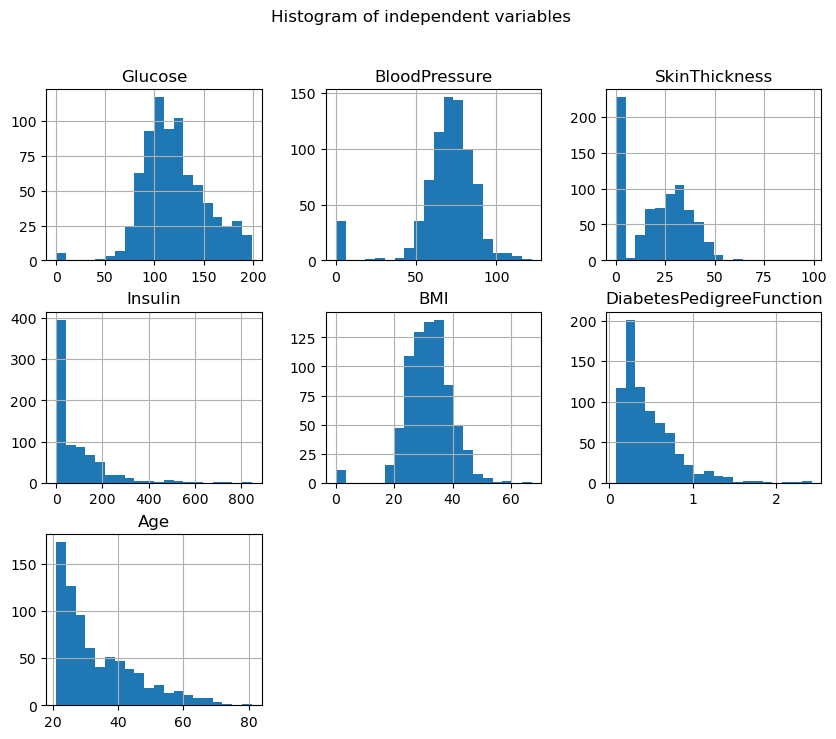

In [7]:
import seaborn as sns

independent_variables = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

df[independent_variables].hist(bins = 20, figsize=(10,8))
plt.suptitle("Histogram of independent variables")
plt.show()

### TASK 2 (Data Preparation)

- Preprocess the data through scaling using the Standard Scaler.

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = df[independent_variables]
y = df["Outcome"]
X_scaled = scaler.fit_transform(X)

- Split the entire data into training and testing datasets with 20% test data.

In [12]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2, random_state=42)

print("Shape of Training data :", X_train.shape)
print("Shape of Test data:", X_test.shape)

Shape of Training data : (614, 7)
Shape of Test data: (154, 7)


### TASK 3 (Model Building)

- Find the optimum K value.

In [15]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

k_range = range(1,20)
k_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train,y_train, cv=5, scoring="accuracy")
    k_scores.append(scores.mean())\

optimal_k = k_range[k_scores.index(max(k_scores))]
print("Optimal K value:", optimal_k)

Optimal K value: 7


- Build a K-Nearest Neighbor classifier model and train the model using the optimum K value.

In [17]:
model = KNeighborsClassifier(n_neighbors=optimal_k, metric= "euclidean")
model.fit(X_train, y_train)

KNeighborsClassifier(metric='euclidean', n_neighbors=7)

- Print properties of model.

In [19]:
print("Number of Neighbours: ", model.n_neighbors)
print("Distance formula used: ", model.effective_metric_)

Number of Neighbours:  7
Distance formula used:  euclidean


### TASK 4 (Evaluate Model Performance)

- Predict whether the person is diabetic or not based on the test data.

In [22]:
y_pred = model.predict(X_test)

- Evaluate performance of the model using evaluation metrics.

In [24]:
from sklearn.metrics import f1_score,accuracy_score,precision_score,recall_score, confusion_matrix

F1_score = f1_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
confusion_mat = confusion_matrix(y_test,y_pred)

print("PERFORMANCE METRICS")
print(f"F1 Score: {F1_score:.2f}")
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"Confusion Matrix: {confusion_mat}")

PERFORMANCE METRICS
F1 Score: 0.62
Accuracy: 0.72
Precision: 0.60
Recall: 0.64
Confusion Matrix: [[76 23]
 [20 35]]


- Write the final interpretation based on the evaluation scores of the model.

### Final Interpretation:
- The model achieved an accuracy of 0.72, indicating 72% correct predictions. Precision of 0.60 shows the accuracy of positive predictions, while recall of 0.64 indicates the ability to identify all positive cases. The F1-score of 0.62 balances precision and recall. The confusion matrix provides insight into true positives, false positives, true negatives, and false negatives.

- The model demonstrates moderate performance across the board. The accuracy of 72% is reasonable, but the F1-score of 0.62, along with precision (0.60) and recall (0.64) being relatively close but not exceptionally high, indicates that the model could be improved.

- The confusion matrix further clarifies these points:

The number of true negatives (76) is significantly higher than true positives (35), suggesting the model is better at identifying negative cases.

The false positives (23) are slightly higher than false negatives (20). This means the model is a bit more prone to incorrectly classifying negative instances as positive than missing actual positive instances.

$In$ $conclusion$, the model is providing acceptable results, but there is clear scope for further optimization to enhance its predictive power and reduce both false positives and false negatives. 